# Single-Cell RNA-seq of 2,700 PBMCs — From Counts to Cell Types

**Author:** [IshanMaheshwari01](https://github.com/IshanMaheshwari01)
**Tools:** Python · [Scanpy](https://scanpy.readthedocs.io) · AnnData · Leiden · UMAP

---

### What is single-cell RNA-seq?

Bulk RNA-seq measures the *average* gene expression of a whole tissue — every
cell's transcripts are pooled together. **Single-cell RNA-seq (scRNA-seq)**
instead measures gene expression in **each individual cell**, so we can discover
the *cell types* that make up a sample and study them separately. The trade-off
is that per-cell data is extremely sparse and noisy: a typical cell has only a
few thousand transcripts detected out of ~20,000 genes.

### The dataset

We analyse the classic **PBMC 3k** dataset from 10x Genomics: **2,700 peripheral
blood mononuclear cells** from a healthy human donor, sequenced on the 10x
Chromium platform. PBMCs are the immune cells in blood — T cells, B cells, NK
cells, monocytes, dendritic cells — which makes this a perfect dataset for
learning, because we know which cell types to expect.

### The goal

Take the raw gene-by-cell count matrix and, with no prior labels, **recover the
known immune cell types** and the marker genes that define them. The workflow:

1. **Quality control** — remove empty droplets, doublets and dying cells
2. **Normalisation** — make cells comparable despite different sequencing depth
3. **Feature selection** — keep the most informative (highly variable) genes
4. **Dimensionality reduction** — PCA, then UMAP for visualisation
5. **Clustering** — group transcriptionally similar cells (Leiden algorithm)
6. **Marker genes** — find what is differentially expressed in each cluster
7. **Annotation** — assign a biological identity to each cluster

## 0. Setup

We import Scanpy and configure plotting. Setting a fixed `random_state`
everywhere keeps the analysis reproducible — UMAP and clustering are stochastic
and would otherwise look slightly different on every run.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 0
np.random.seed(SEED)

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=90, facecolor="white", frameon=False)

# data lives at <project_root>/data/... ; this notebook lives in notebooks/
DATA_DIR = Path("..") / "data" / "pbmc3k" / "filtered_gene_bc_matrices" / "hg19"
print("scanpy", sc.__version__)

scanpy 1.12.1


/tmp/ipykernel_908/1330830950.py:11: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=90, facecolor="white", frameon=False)
/tmp/ipykernel_908/1330830950.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", sc.__version__)


## 1. Load the data

10x Cell Ranger outputs three files that together encode a sparse count matrix:

| file | contents |
|------|----------|
| `matrix.mtx` | the counts: how many of each gene were seen in each cell |
| `genes.tsv` | the gene names (rows) |
| `barcodes.tsv` | the cell barcodes (columns) |

Scanpy reads them into an **AnnData** object — the central data structure that
holds the expression matrix (`.X`), per-cell metadata (`.obs`) and per-gene
metadata (`.var`) side by side.

In [2]:
adata = sc.read_10x_mtx(DATA_DIR, var_names="gene_symbols", cache=True)
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

`n_obs × n_vars = 2700 × 32738` means **2,700 cells** and **32,738 genes**. The
matrix is ~97% zeros — most genes are simply not detected in most cells. That
sparsity is normal and is exactly why the steps below are necessary.

## 2. Quality control (QC)

A "cell" here is really a **droplet barcode**, and not every barcode is a healthy
single cell. We compute three diagnostics and use them to filter:

- **`n_genes_by_counts`** — number of distinct genes detected in a cell.
  *Too few* → empty droplet or debris. *Too many* → likely a **doublet** (two
  cells captured in one droplet).
- **`total_counts`** — total transcripts (UMIs) per cell; reflects sequencing depth.
- **`pct_counts_mt`** — % of counts from **mitochondrial** genes (symbols start
  with `MT-`). When a cell is stressed or dying its membrane ruptures, cytoplasmic
  mRNA leaks out, and the mitochondrial fraction shoots up. High `pct_counts_mt`
  is the classic signature of a low-quality cell.

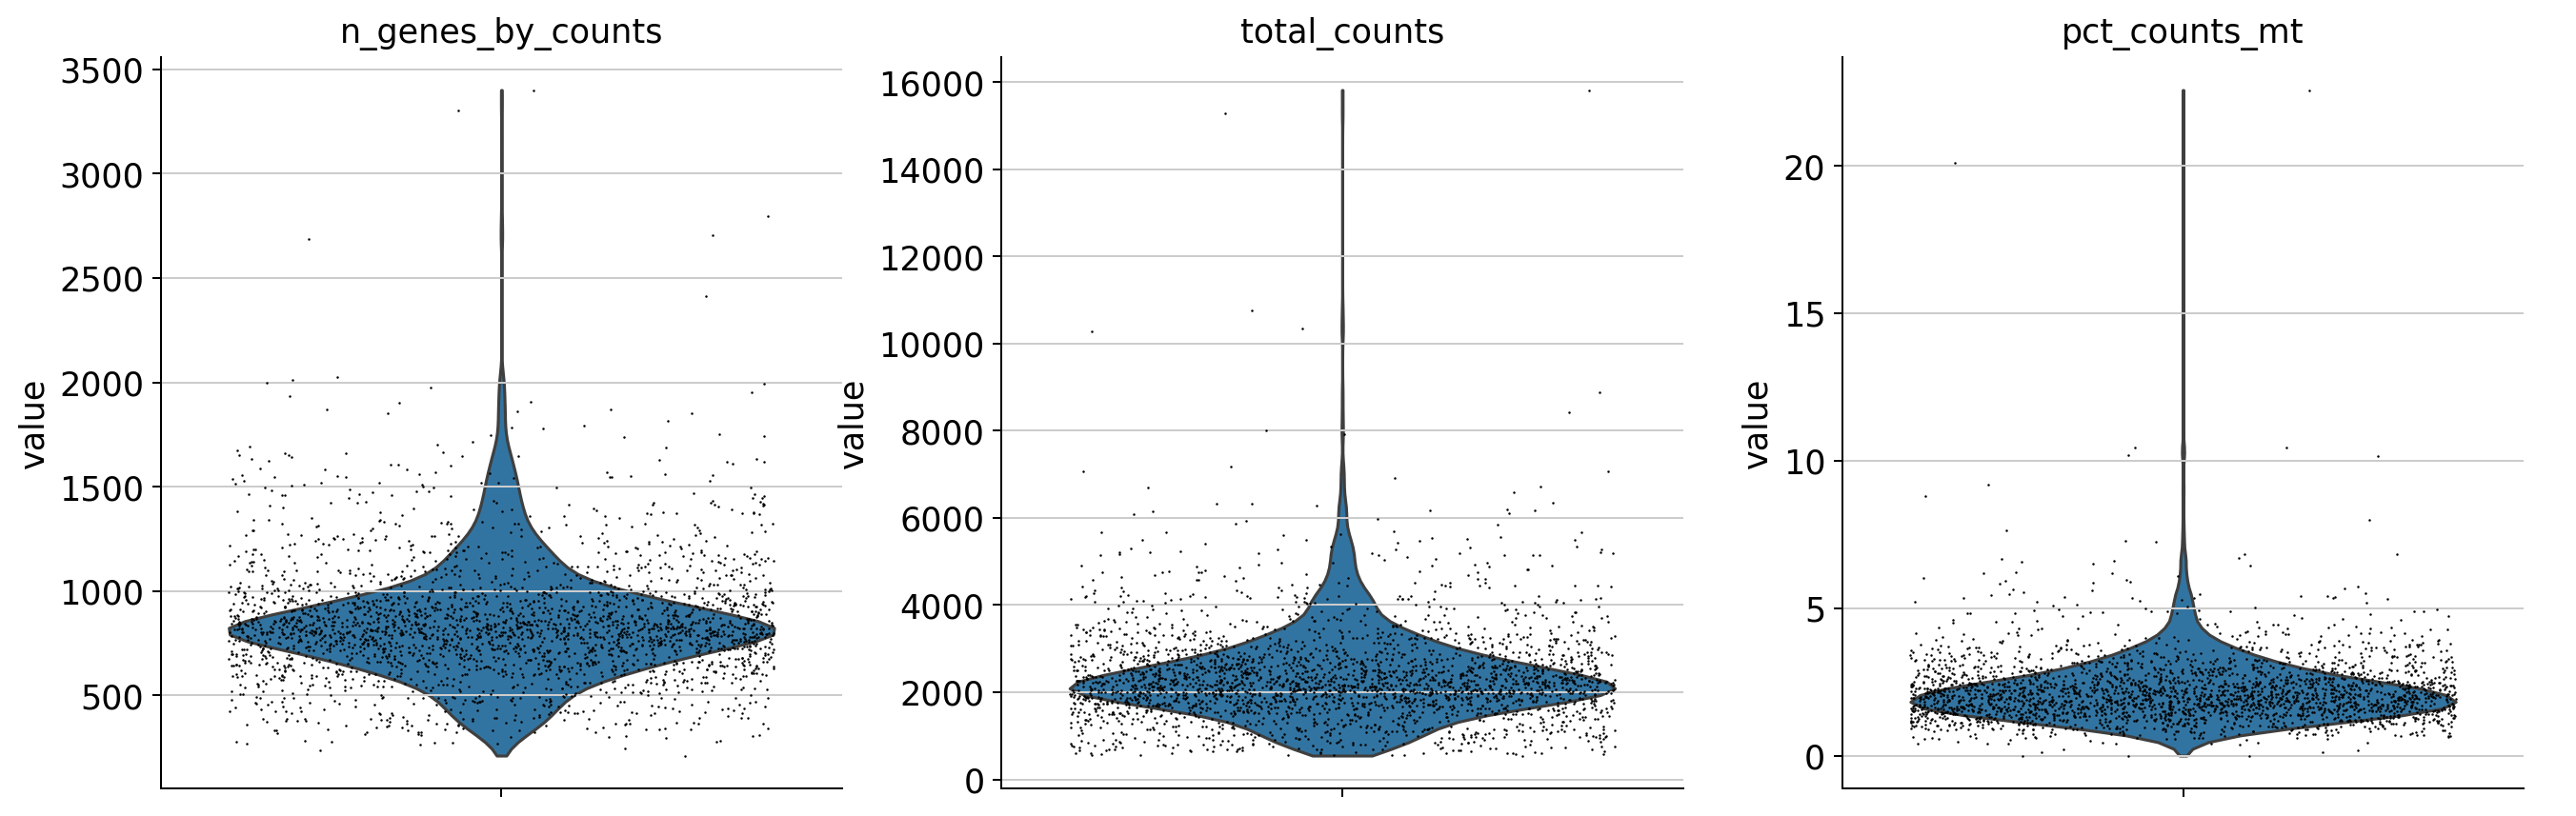

In [3]:
# light pre-filter: drop near-empty barcodes and genes seen in <3 cells
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# flag mitochondrial genes and compute standard QC metrics
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None,
                           log1p=False, inplace=True)

sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
             jitter=0.4, multi_panel=True)

The scatter plots below show *why* we filter on these jointly. Cells with very
high mitochondrial percentage (left) or an unusually large number of genes
(right, upper tail) are the ones we want to exclude.

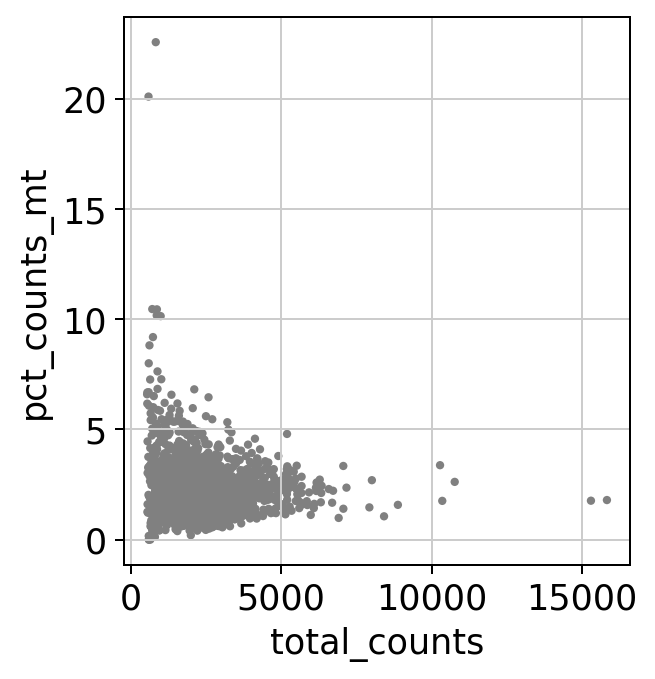

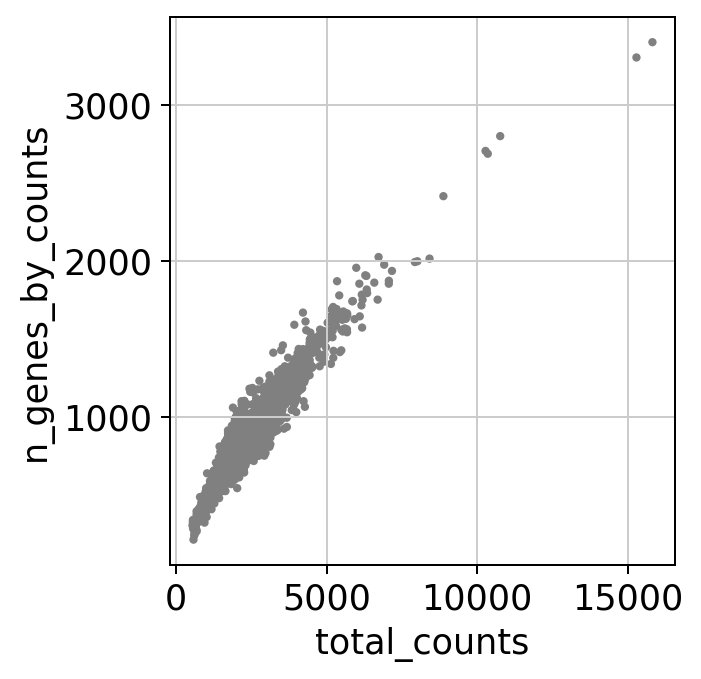

In [4]:
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

In [5]:
n_before = adata.n_obs
adata = adata[adata.obs.n_genes_by_counts < 2500, :].copy()  # remove doublets
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()         # remove dying cells
print(f"kept {adata.n_obs} / {n_before} cells after QC")

kept 2638 / 2700 cells after QC


## 3. Normalisation & log-transform

A cell sequenced twice as deeply will show roughly twice the counts everywhere —
that is a **technical** difference, not biology. We remove it in two steps:

1. **Library-size normalisation** (`normalize_total`, target = 10,000): rescale
   every cell so its counts sum to the same total (counts-per-10k, "CP10K").
2. **Log-transform** (`log1p`, i.e. `log(1+x)`): expression is highly skewed;
   the log compresses the dynamic range so a handful of very highly expressed
   genes don't dominate distances between cells.

In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## 4. Highly variable genes (feature selection)

Of the ~13,700 remaining genes, most are housekeeping genes that look the same
in every cell and carry no information about cell identity. We keep only the
**highly variable genes (HVGs)** — those whose variability across cells exceeds
what technical noise alone would produce. This denoises the data and speeds
everything up.

We then freeze a copy of the full log-normalised matrix in `adata.raw` (so we
can still plot *any* gene later), and subset the working matrix to the HVGs.

1838 highly variable genes selected


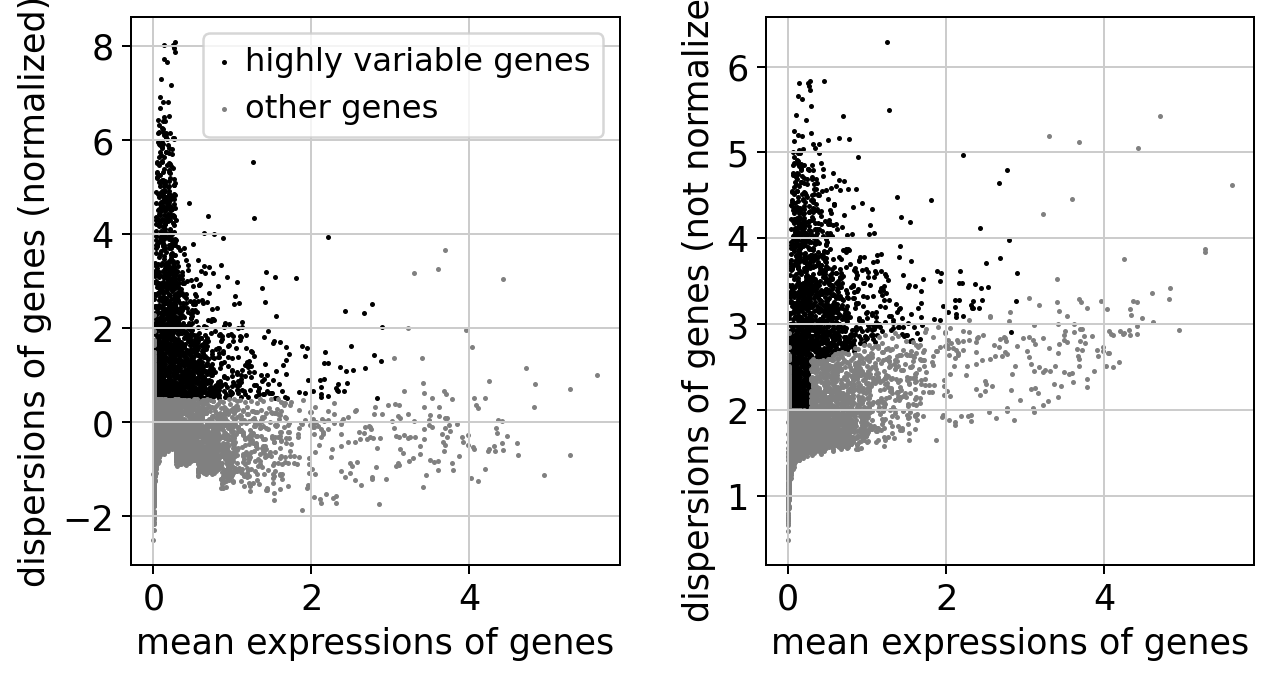

In [7]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
print(f"{int(adata.var.highly_variable.sum())} highly variable genes selected")
sc.pl.highly_variable_genes(adata)

In [8]:
adata.raw = adata                                  # keep all genes for plotting
adata = adata[:, adata.var.highly_variable].copy() # work with HVGs only

## 5. Scaling & PCA

Before linear dimensionality reduction we:

- **Regress out** the influence of total counts and mitochondrial fraction, so
  residual technical variation doesn't drive the structure.
- **Scale** each gene to mean 0 / unit variance and clip to ±10, so that PCA
  treats genes evenly rather than being dominated by a few high-variance ones.

**PCA** then finds the directions of greatest variation. We keep the top
principal components as a compact, denoised representation of each cell. The
"elbow" in the variance plot tells us how many PCs carry real signal.

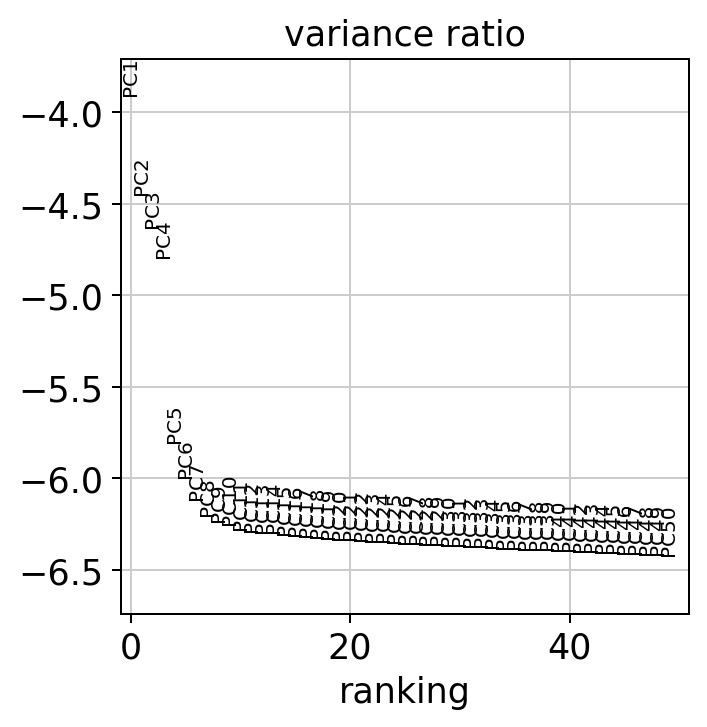

In [9]:
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack", random_state=SEED)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

## 6. Neighbourhood graph, UMAP & clustering

Now we move from "cells in PCA space" to "groups of similar cells":

- **kNN graph** (`neighbors`): connect each cell to its *k* most similar cells
  (here using the top 40 PCs). This graph captures the manifold the cells live on.
- **UMAP** (`umap`): a 2-D embedding of that graph **for visualisation only** —
  nearby points are similar cells. We do *not* cluster on the 2-D coordinates.
- **Leiden clustering** (`leiden`): a community-detection algorithm that finds
  densely connected groups in the graph. Each community is a candidate cell type.

Leiden found 8 clusters


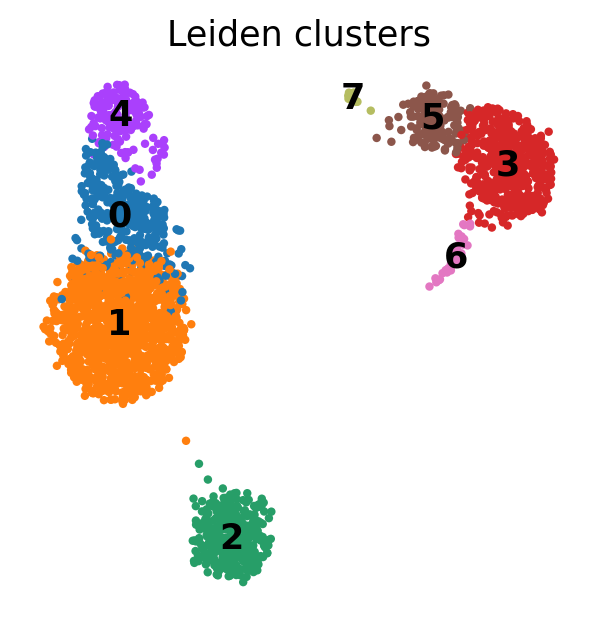

In [10]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40, random_state=SEED)
sc.tl.umap(adata, random_state=SEED)
sc.tl.leiden(adata, resolution=1.0, random_state=SEED,
             flavor="igraph", n_iterations=2, directed=False)
print(f"Leiden found {adata.obs['leiden'].nunique()} clusters")
sc.pl.umap(adata, color="leiden", legend_loc="on data", title="Leiden clusters")

Colouring the same UMAP by the QC metrics is a good sanity check: if a cluster
were defined purely by sequencing depth or mitochondrial content (a technical
artefact) rather than biology, it would light up here. It doesn't — good.

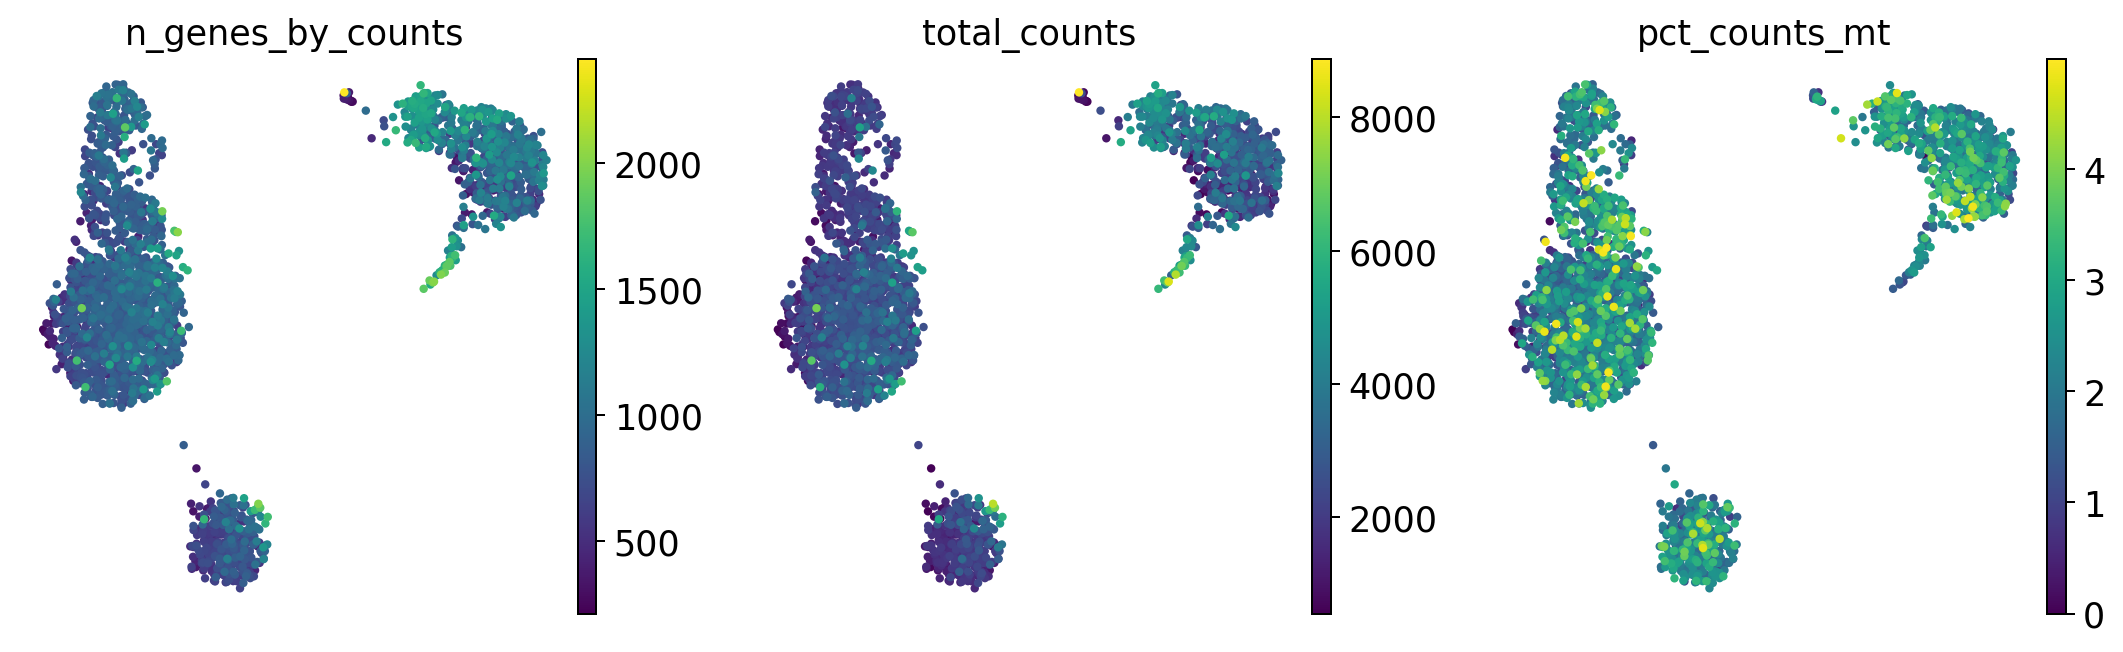

In [11]:
sc.pl.umap(adata, color=["n_genes_by_counts", "total_counts", "pct_counts_mt"])

## 7. Marker genes — what defines each cluster?

For every cluster we run a **one-vs-rest differential expression test**
(Wilcoxon rank-sum) to find the genes most specifically up-regulated in that
cluster. These **marker genes** are how we will name the clusters.

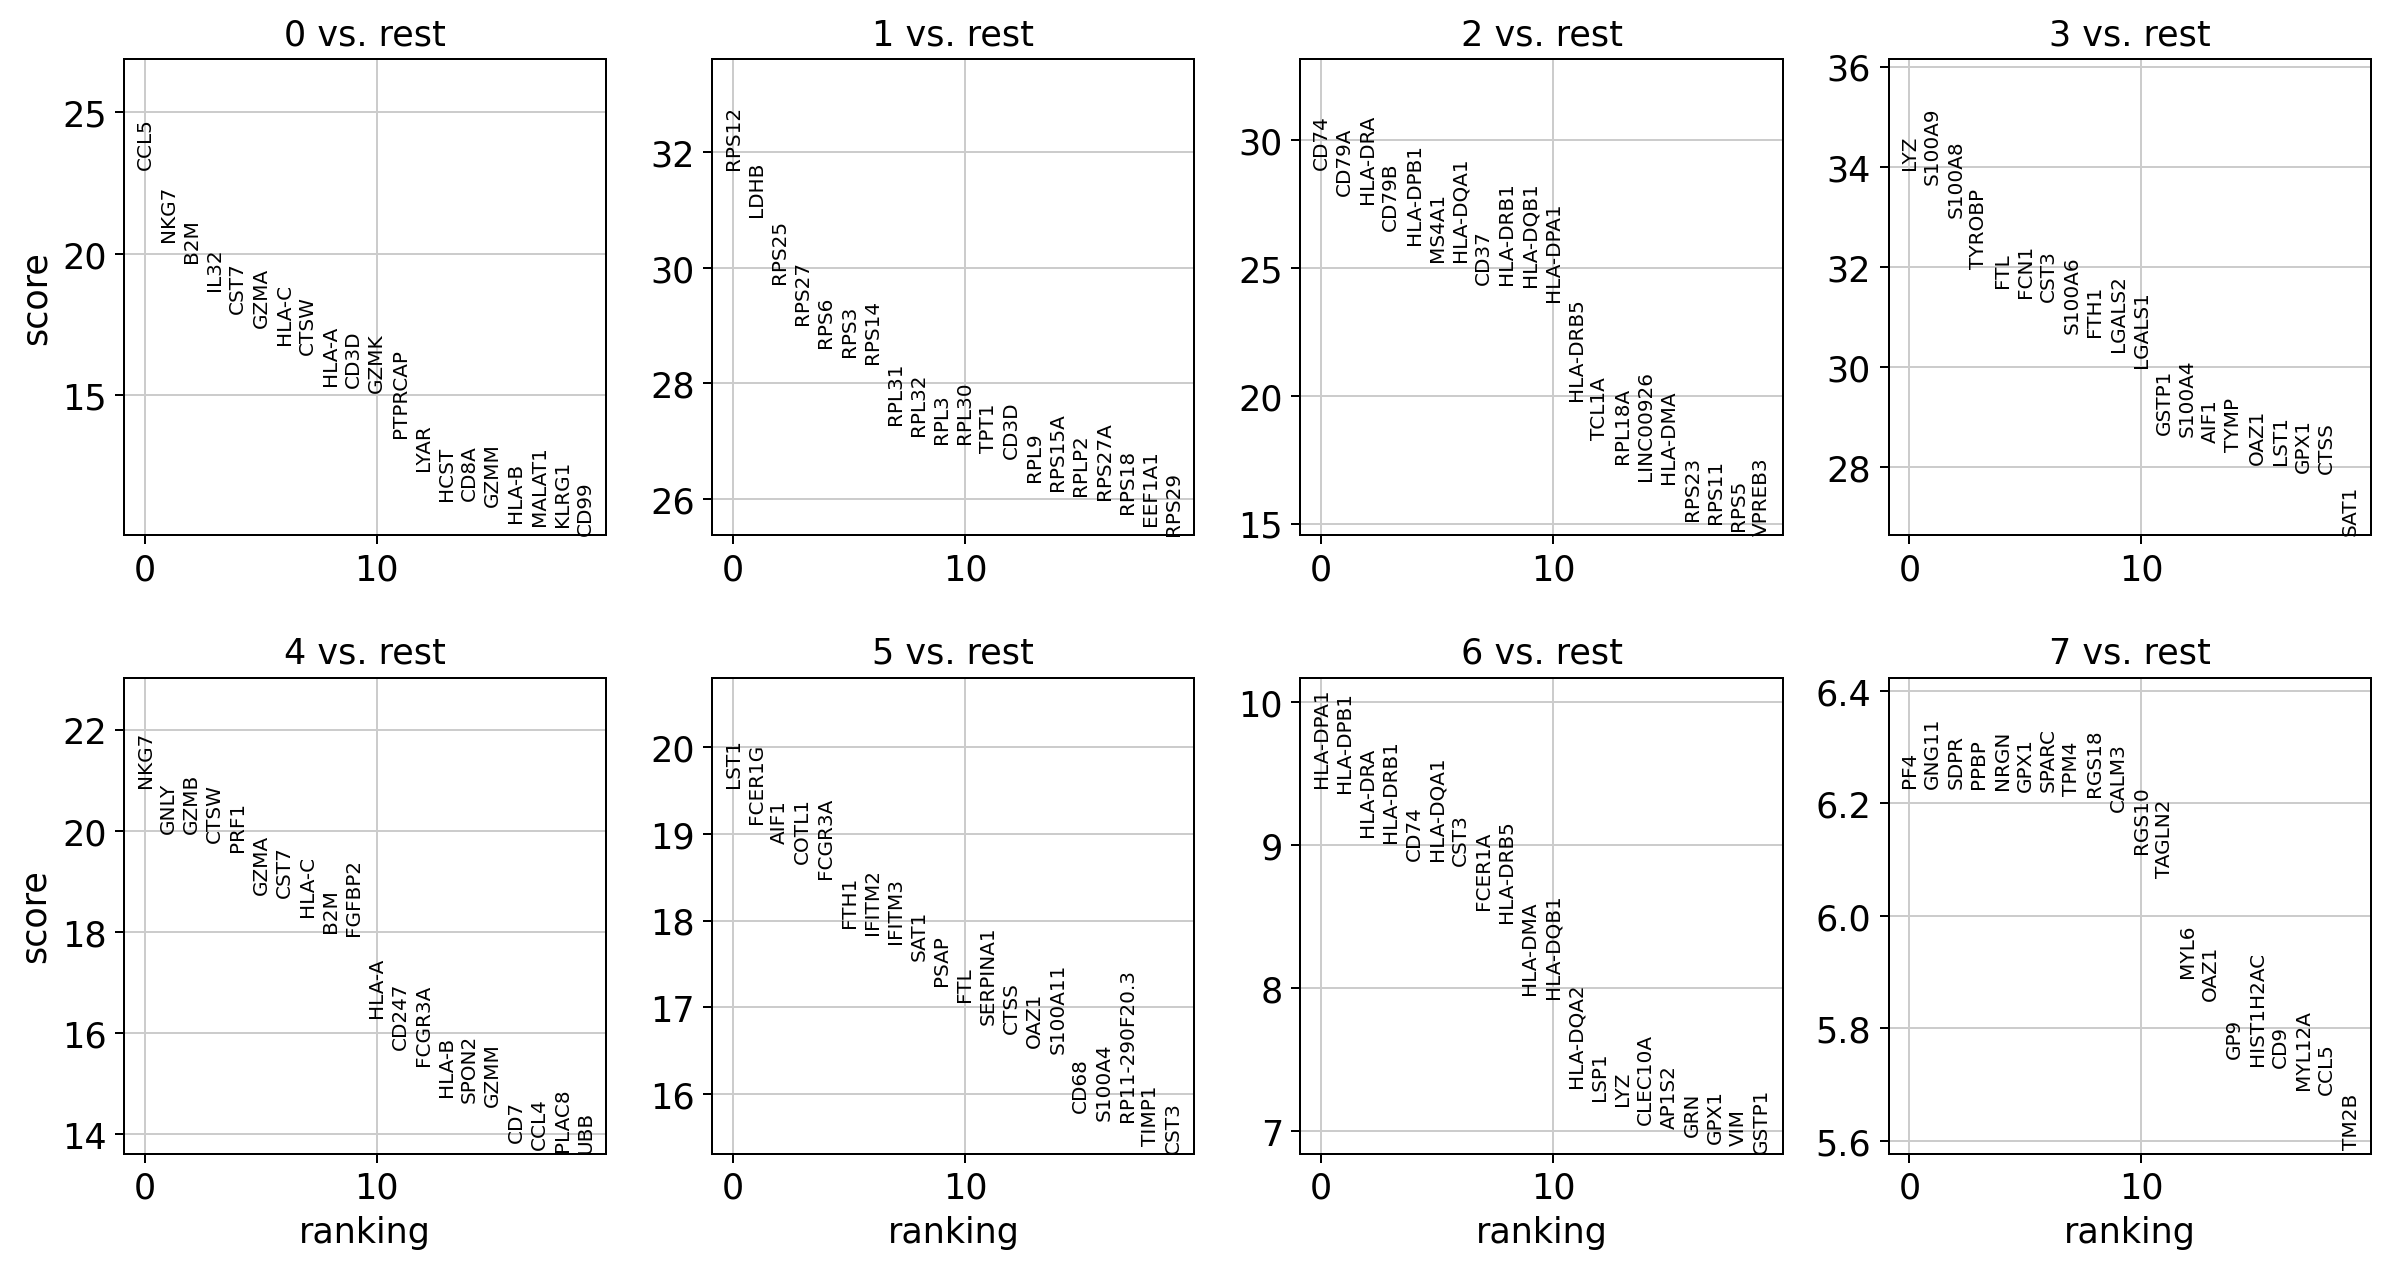

In [12]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon", use_raw=True)
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

In [13]:
# top 5 markers per cluster, as a tidy table
top = sc.get.rank_genes_groups_df(adata, group=None)
top.groupby("group").head(5).reset_index(drop=True)

/tmp/ipykernel_908/650355692.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top.groupby("group").head(5).reset_index(drop=True)


,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,CCL5,22.997122,4.966028,4.980882e-117,6.830781e-113
1,0,NKG7,20.459600,4.425384,4.934055e-93,3.383281e-89
2,0,B2M,19.708570,0.762802,1.820400e-86,8.321654e-83
3,0,IL32,18.723589,2.672220,3.179871e-78,1.090219e-74
4,0,CST7,17.885736,3.876401,1.523284e-71,4.178063e-68
5,1,RPS12,31.712969,1.036235,1.029449e-220,1.411786e-216
6,1,LDHB,30.894955,2.598322,1.396162e-209,9.573482e-206
7,1,RPS25,29.742329,1.154973,2.179159e-194,5.976996e-191
8,1,RPS27,29.031122,1.006427,2.664078e-185,6.089195e-182
9,1,RPS6,28.624720,0.857145,3.309427e-180,5.673185e-177


## 8. Do the markers match known immune cell types?

We compare each cluster against **canonical PBMC marker genes** from immunology.
The dotplot encodes two things at once: **colour** = mean expression, **dot size**
= fraction of cells in the cluster expressing the gene. A clean diagonal means
each cluster has its own marker signature.

| Cell type | Canonical markers |
|-----------|-------------------|
| CD4 T cells | IL7R, CD3D, CCR7 |
| CD8 T cells | CD8A, CD8B, GZMK |
| NK cells | GNLY, NKG7, KLRD1 |
| B cells | MS4A1, CD79A, CD79B |
| CD14+ Monocytes | CD14, LYZ, S100A8/9 |
| FCGR3A+ Monocytes | FCGR3A, MS4A7 |
| Dendritic cells | FCER1A, CST3 |
| Megakaryocytes | PPBP, PF4 |

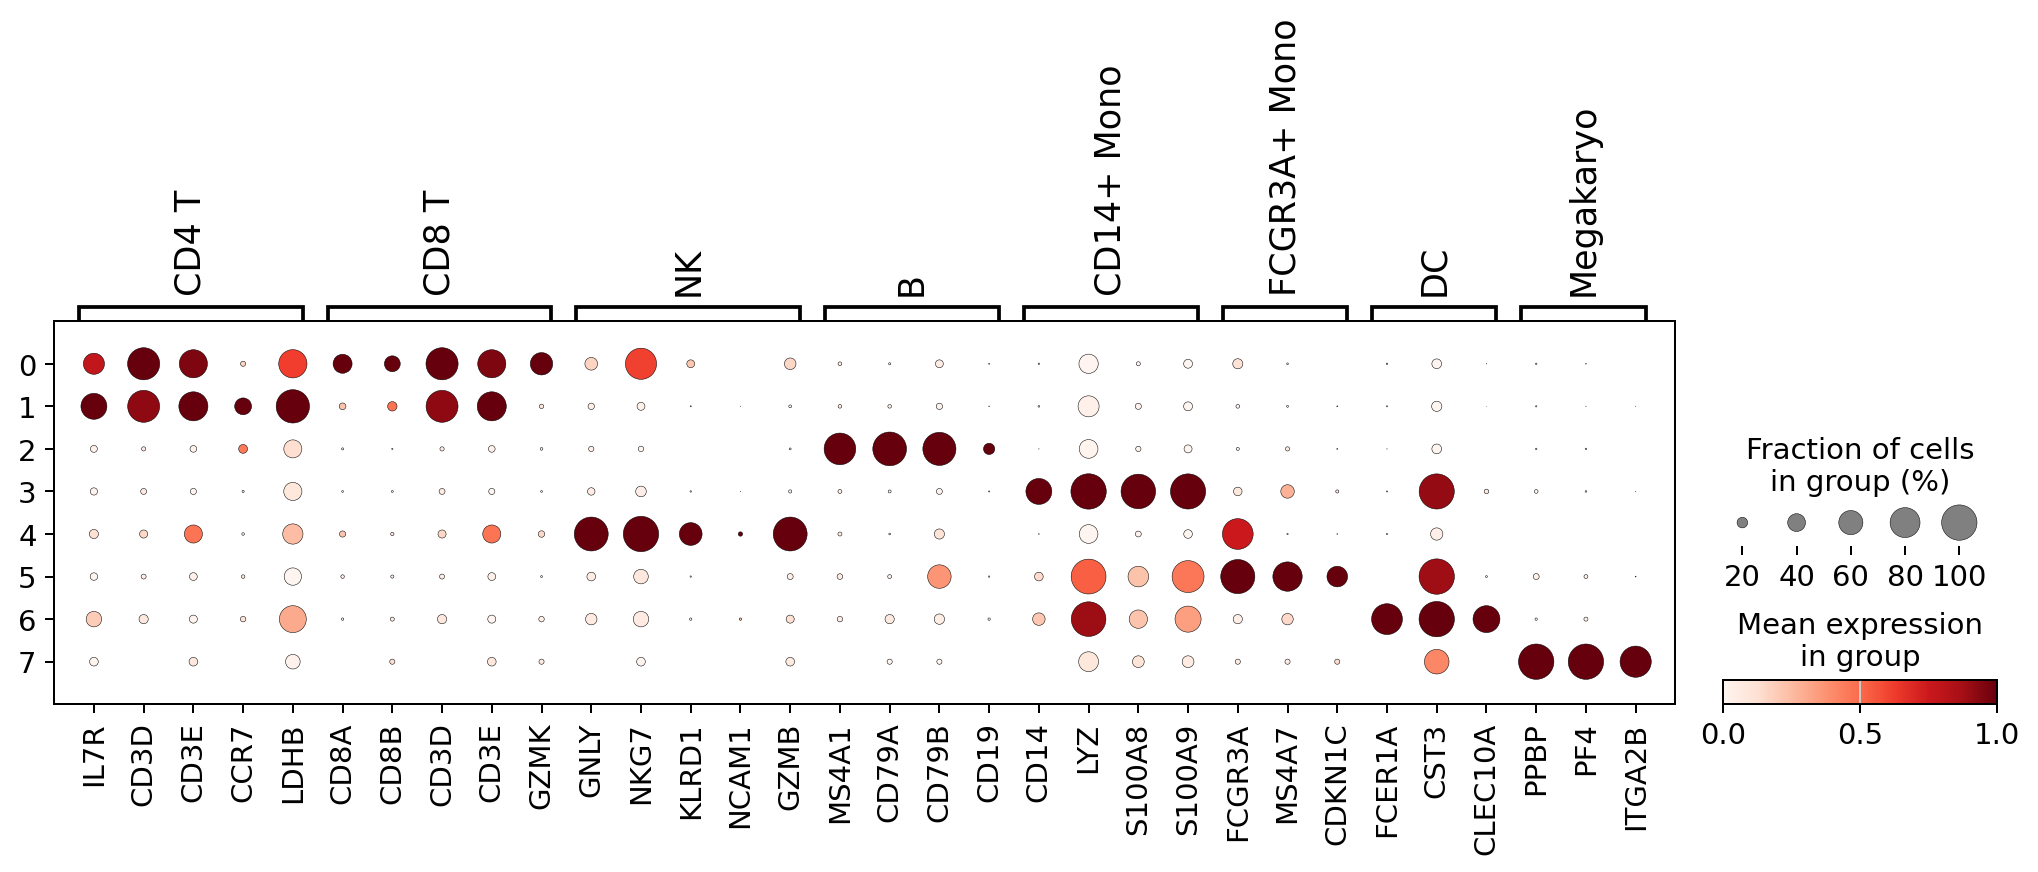

In [14]:
marker_sets = {
    "CD4 T":        ["IL7R", "CD3D", "CD3E", "CCR7", "LDHB"],
    "CD8 T":        ["CD8A", "CD8B", "CD3D", "CD3E", "GZMK"],
    "NK":           ["GNLY", "NKG7", "KLRD1", "NCAM1", "GZMB"],
    "B":            ["MS4A1", "CD79A", "CD79B", "CD19"],
    "CD14+ Mono":   ["CD14", "LYZ", "S100A8", "S100A9"],
    "FCGR3A+ Mono": ["FCGR3A", "MS4A7", "CDKN1C"],
    "DC":           ["FCER1A", "CST3", "CLEC10A"],
    "Megakaryo":    ["PPBP", "PF4", "ITGA2B"],
}
sc.pl.dotplot(adata, marker_sets, groupby="leiden",
              use_raw=True, standard_scale="var")

## 9. Annotate the clusters

We assign each cluster the cell type whose markers it expresses most strongly
(scored by mean z-scored expression across clusters). Doing it data-driven —
rather than hard-coding "cluster 3 = CD8 T" — keeps the analysis robust to the
exact cluster numbering, which can shuffle between software versions.

In [15]:
raw = adata.raw.to_adata()
clusters = sorted(adata.obs["leiden"].cat.categories, key=int)
genes = sorted({g for v in marker_sets.values() for g in v if g in set(raw.var_names)})

# mean expression of each marker gene per cluster, z-scored across clusters
expr = pd.DataFrame(
    {cl: np.asarray(raw[(adata.obs.leiden == cl).values, genes].X.mean(0)).ravel()
     for cl in clusters},
    index=genes,
).T
z = (expr - expr.mean(0)) / (expr.std(0) + 1e-9)

score = pd.DataFrame(
    {ct: z[[g for g in gs if g in genes]].mean(1) for ct, gs in marker_sets.items()}
)
mapping = score.idxmax(1).to_dict()
mapping

{'0': 'CD8 T',
 '1': 'CD4 T',
 '2': 'B',
 '3': 'CD14+ Mono',
 '4': 'NK',
 '5': 'FCGR3A+ Mono',
 '6': 'DC',
 '7': 'Megakaryo'}

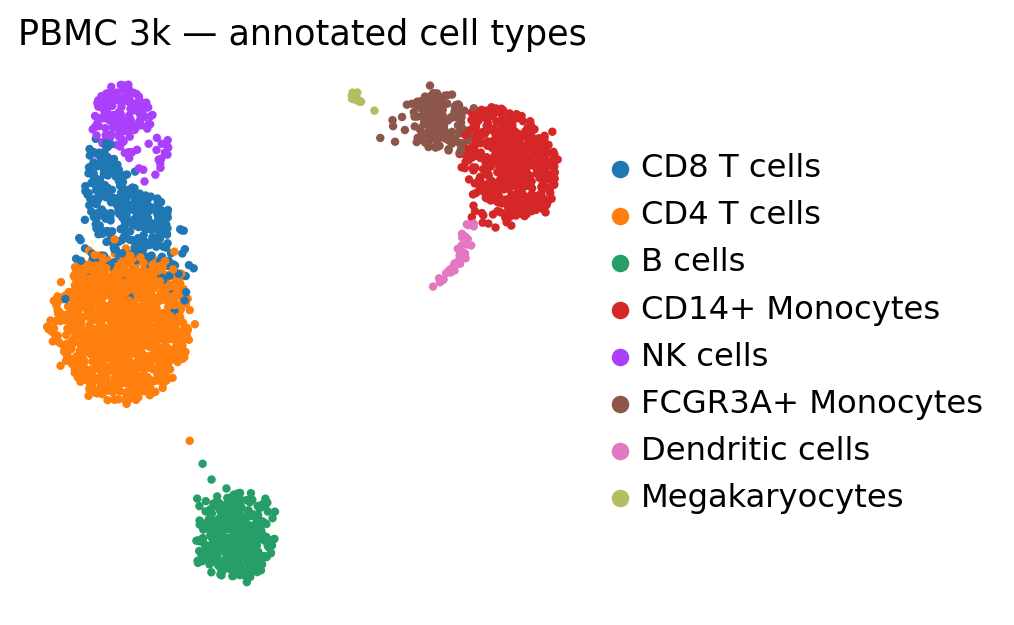

In [16]:
full_names = {
    "CD4 T": "CD4 T cells", "CD8 T": "CD8 T cells", "NK": "NK cells",
    "B": "B cells", "CD14+ Mono": "CD14+ Monocytes",
    "FCGR3A+ Mono": "FCGR3A+ Monocytes", "DC": "Dendritic cells",
    "Megakaryo": "Megakaryocytes",
}
adata.obs["cell_type"] = (
    adata.obs["leiden"].map(lambda c: full_names[mapping[c]]).astype("category")
)
sc.pl.umap(adata, color="cell_type", legend_loc="right margin",
           title="PBMC 3k — annotated cell types")

## 10. Confirm with single-marker feature plots

A final visual check: overlay one canonical marker per lineage on the UMAP.
Each marker should light up exactly one region, matching our annotation.

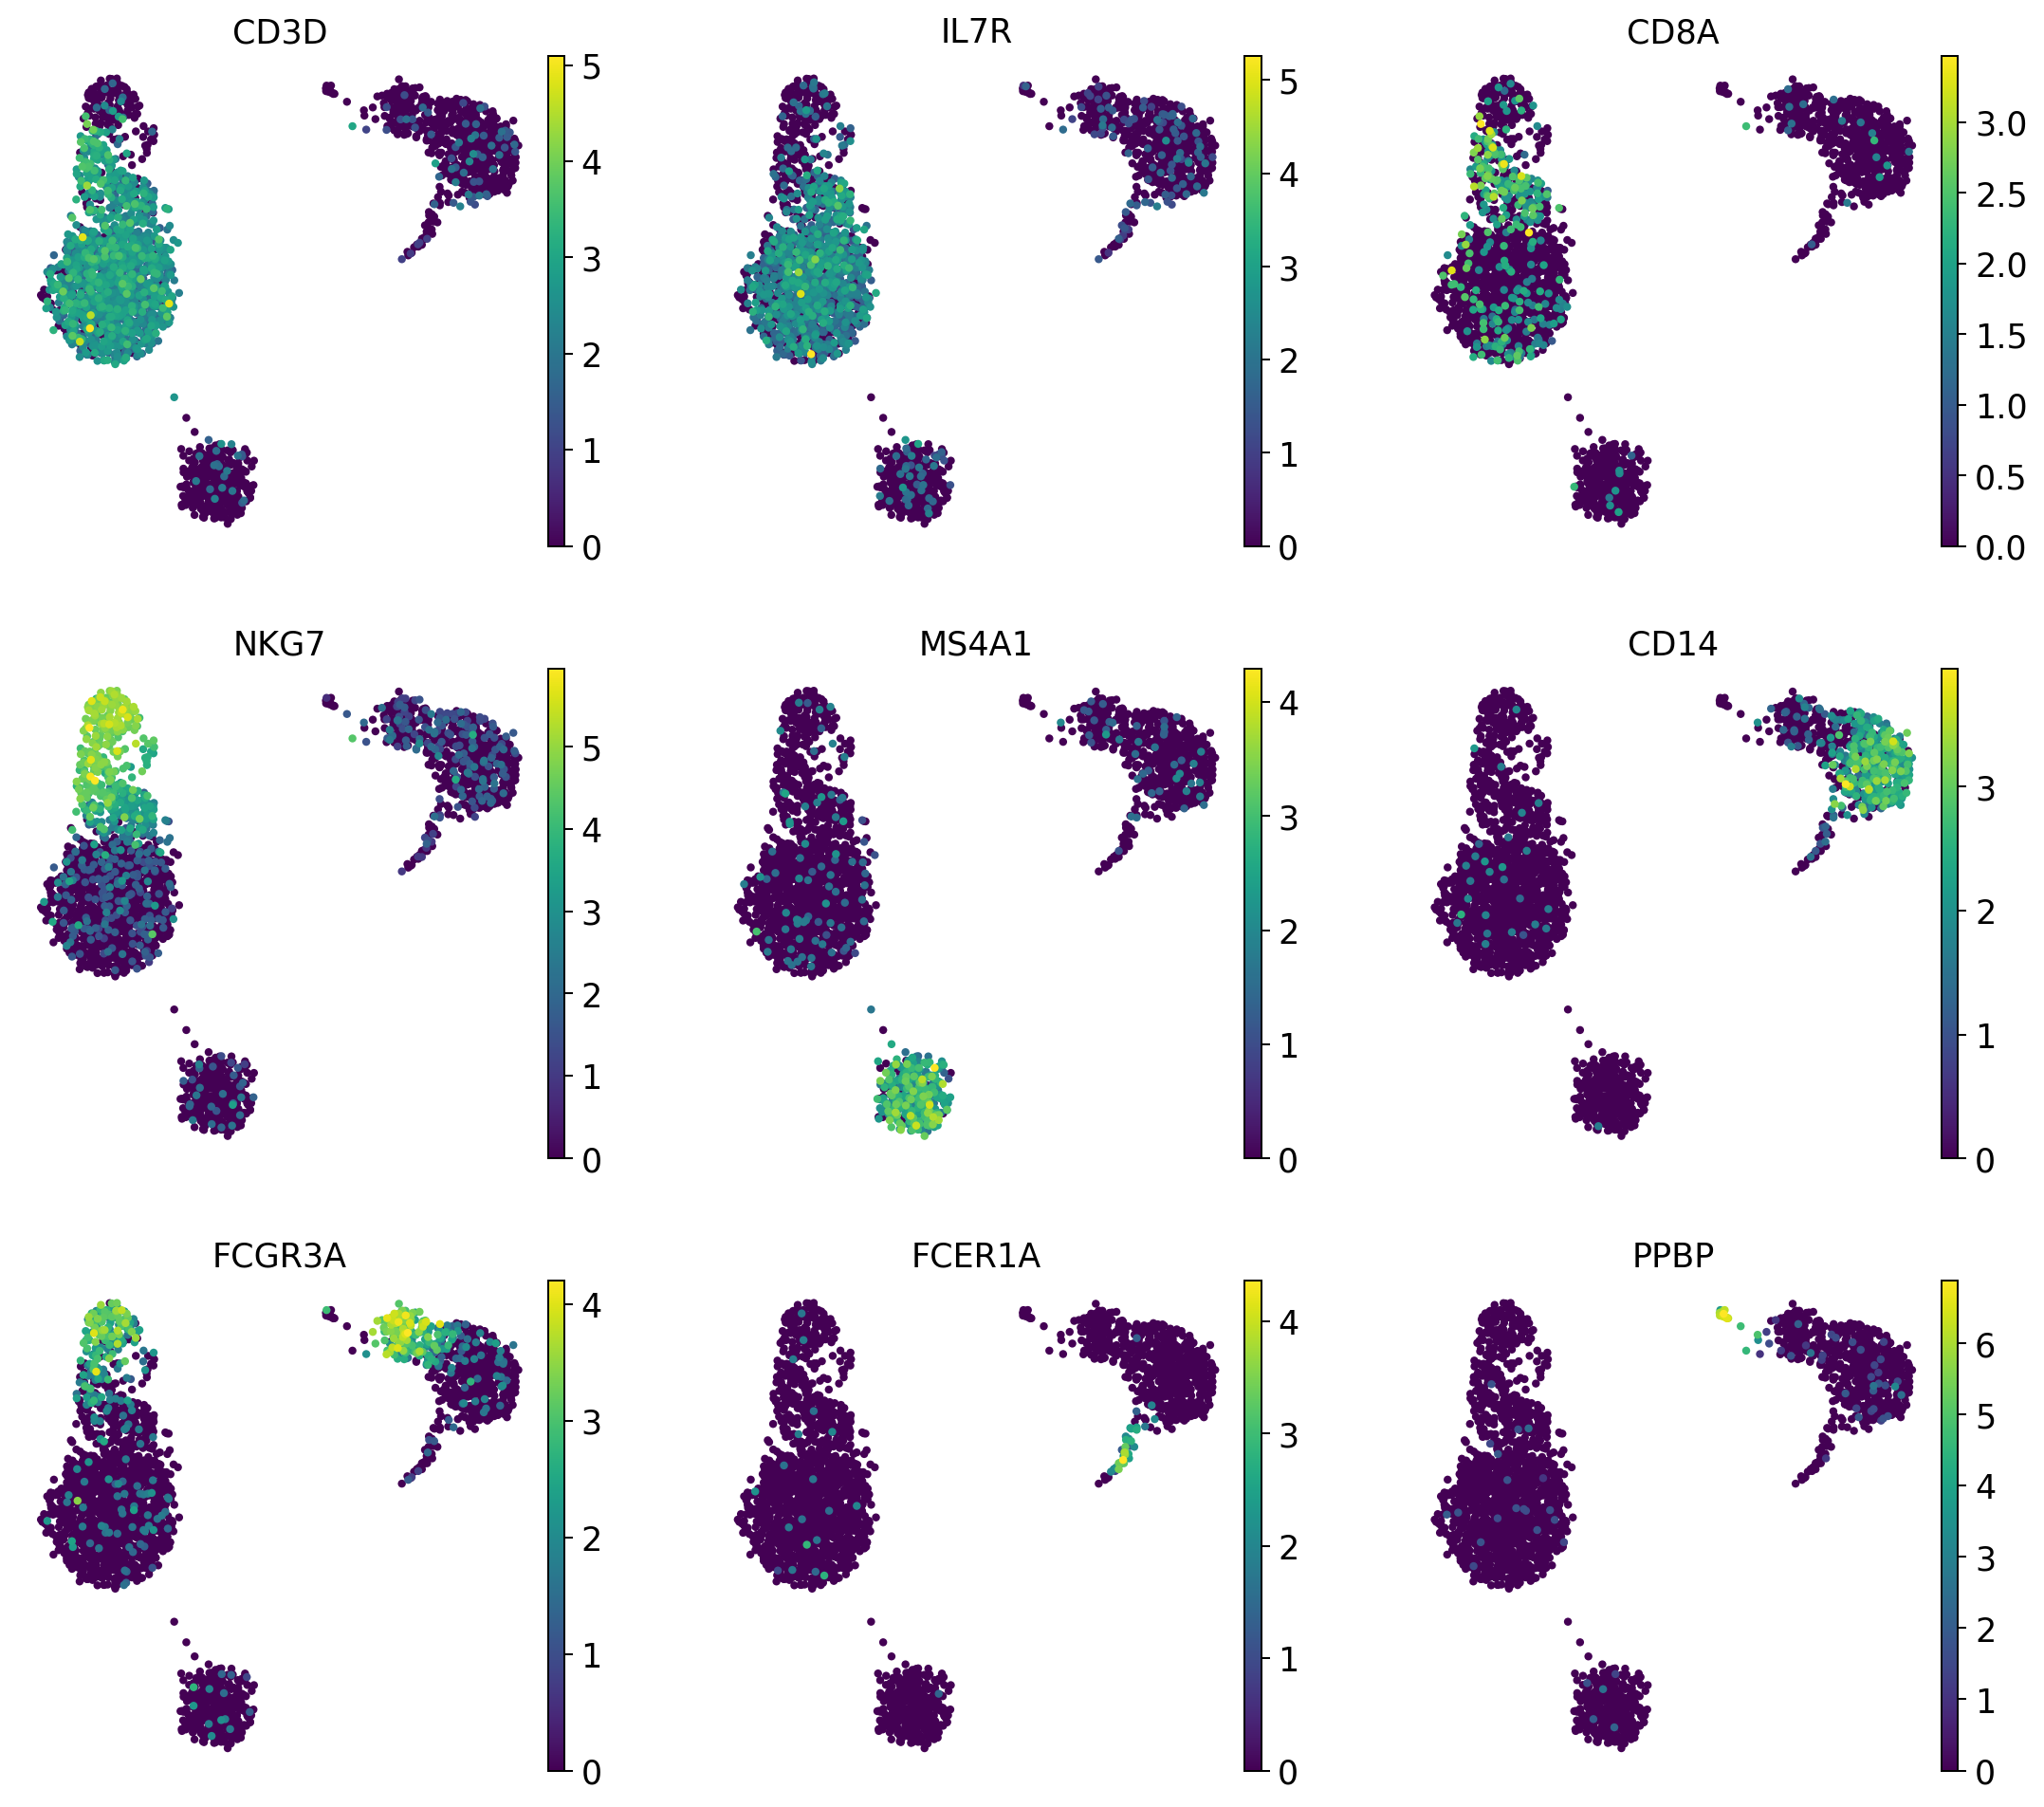

In [17]:
sc.pl.umap(adata, color=["CD3D", "IL7R", "CD8A", "NKG7", "MS4A1",
                         "CD14", "FCGR3A", "FCER1A", "PPBP"],
           use_raw=True, ncols=3)

## 11. Cell-type composition

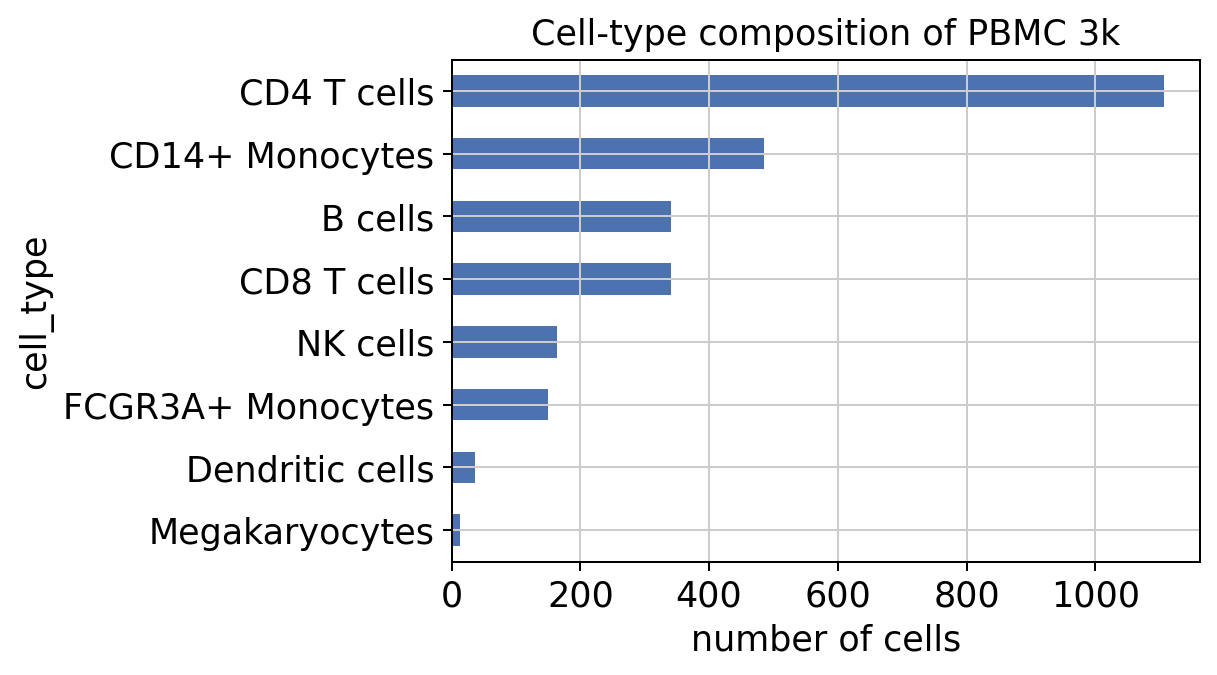

,n_cells
cell_type,
CD4 T cells,1107
CD14+ Monocytes,486
CD8 T cells,341
B cells,341
NK cells,164
FCGR3A+ Monocytes,150
Dendritic cells,36
Megakaryocytes,13


In [18]:
counts = adata.obs["cell_type"].value_counts()
ax = counts.sort_values().plot(kind="barh", figsize=(7, 4), color="#4C72B0")
ax.set_xlabel("number of cells"); ax.set_title("Cell-type composition of PBMC 3k")
plt.tight_layout(); plt.show()
counts.to_frame("n_cells")

## Conclusion

Starting from a raw, unlabelled 2,700 × 32,738 count matrix, the pipeline
recovered **eight transcriptionally distinct immune populations** and assigned
each a biological identity from canonical markers — **T cells (CD4 & CD8), NK
cells, B cells, two monocyte subsets, dendritic cells and megakaryocytes** — the
exact composition expected of human peripheral blood. T cells dominate (as in
real blood), and even the rare megakaryocyte population (a few dozen cells) was
cleanly separated.

**What this demonstrates**

- The full standard scRNA-seq workflow: QC → normalisation → HVG → PCA → kNN
  graph → UMAP → Leiden clustering → differential expression → annotation
- Fluency with **Scanpy / AnnData** and reproducible, seeded analysis
- Connecting computational clusters back to **real biology** via marker genes

**Where to go next:** cell-cycle regression, doublet detection (Scrublet),
trajectory / pseudotime analysis, batch integration across donors (Harmony /
scVI), and automated reference-based annotation (CellTypist).